# Task 3-6: Clinical Supply Demand Forecasting

## Complete Workflow: From Baseline to Scenario Analysis

This notebook implements the complete demand forecasting workflow:
1. **Task 3**: Baseline Demand Calculation
2. **Task 4**: Scenario Modeling  
3. **Task 5**: Demand Comparison & Variance Analysis
4. **Task 6**: Visualization & Interactive Presentation

### Overview
We'll use trial enrollment and dosing data from Snowflake to:
- Calculate baseline demand by month, country, and item
- Apply scenario adjustments (e.g., enrollment reductions by region)
- Compare scenarios and measure variance
- Visualize results with interactive charts

In [1]:
import sys
import os

# Add parent directory to path to import src modules
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Import our custom modules
from src.demand_calculator import (
    compute_baseline_demand,
    get_baseline_demand_summary
)
from src.data_loader import execute_query

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Section 1: Baseline Demand Calculation (Task 3)

### Process Overview
The baseline demand calculation process:

1. **Load Data**: Fetch enrollments, dosing intervals, countries, and items
2. **Join Data**: Match enrollments with dosing intervals by cohort and treatment group
3. **Calculate Consumption Months**: enrollment_month + dosing_interval_number
4. **Compute Demand**: planned_enrollments × qty × (1 + overage)
5. **Round Up**: Use ceiling to get whole units
6. **Aggregate**: Group by month, country, and item
7. **Validate**: Spot checks to verify calculation accuracy

### Formula
```
Demand(month, country, item) = SUM(Enrollments × BaseDoseQty × (1 + Overage))
where enrollment is in the starting month and dose is in the specified interval
```

In [2]:
# Configuration: Select Trial and Versions
# You can modify these values to analyze different trials

TRIAL_SEQ = 1  # Trial sequence to analyze
ENROLL_VERSION = None  # None = latest version
DOSAGE_VERSION = None  # None = latest version

print(f"Configuration:")
print(f"  TRIAL_SEQ: {TRIAL_SEQ}")
print(f"  ENROLL_VERSION: {ENROLL_VERSION} (will use latest if None)")
print(f"  DOSAGE_VERSION: {DOSAGE_VERSION} (will use latest if None)")

# Get available trials for reference
trials_query = "SELECT DISTINCT TRIAL_SEQ, TRIAL_ID FROM TRIALS ORDER BY TRIAL_SEQ"
trials = execute_query(trials_query)
print(f"\nAvailable trials in database:")
print(trials.to_string(index=False))

Configuration:
  TRIAL_SEQ: 1
  ENROLL_VERSION: None (will use latest if None)
  DOSAGE_VERSION: None (will use latest if None)

Available trials in database:
 TRIAL_SEQ TRIAL_ID
         1  TRIAL-1
         2  TRIAL-2
         3  TRIAL-3
         4  TRIAL-4
         5  TRIAL-5
         6  TRIAL-6
         7  TRIAL-7
         8  TRIAL-8
         9  TRIAL-9
        10 TRIAL-10
        11 TRIAL-11
        12 TRIAL-12
        13 TRIAL-13
        14 TRIAL-14
        15 TRIAL-15
        16 TRIAL-16
        17 TRIAL-17
        18 TRIAL-18
        19 TRIAL-19
        20 TRIAL-20
        21 TRIAL-21
        22 TRIAL-22
        23 TRIAL-23
        24 TRIAL-24


In [3]:
# Step 1: Compute Baseline Demand
baseline_demand = compute_baseline_demand(
    trial_seq=TRIAL_SEQ,
    enroll_version=ENROLL_VERSION,
    dosage_version=DOSAGE_VERSION,
    verbose=True
)

print("Baseline Demand Summary:")
print(baseline_demand.head(10))
print(f"\nShape: {baseline_demand.shape}")
print(f"Columns: {list(baseline_demand.columns)}")


COMPUTING BASELINE DEMAND FOR TRIAL_SEQ=1

1. Loading data from Snowflake...
   ✓ Enrollments loaded: 1080 rows
   ✓ Dosing intervals loaded: 1080 rows
   ✓ Countries loaded: 5 rows
   ✓ Items loaded: 5 rows

2. Validating data integrity...
   ✓ No missing join keys
   ✓ Total patients in enrollments: 15,919

3. Joining enrollments with dosing intervals...
   ✓ Merged data: 129600 rows

4. Calculating consumption months and demand...
   ✓ Aggregating demand by month, country, and item...

5. Validation Summary:
   ✓ Total demand records: 1175
   ✓ Total demand quantity: 5,571,768 units
   ✓ Total patients: 1,910,280
   ✓ Consumption months range: 2 - 48
   ✓ Countries: 5
   ✓ Items: 5

6. Spot Check (First Enrollment Record):
   - Enrollments: 12
   - Base Qty: 2
   - Overage: 0.102
   - Calculated Demand: 12 × 2 × (1 + 0.102) = 26.45
   - Rounded Demand: 27.0


Baseline Demand Summary:
   CONSUMPTION_MONTH COUNTRY  ITEM_SEQ ITEM_ID  DEMAND_QTY  PATIENT_COUNT  \
0                  2  

In [4]:
# Get baseline summary
baseline_summary = get_baseline_demand_summary(baseline_demand)

print("="*80)
print("BASELINE DEMAND SUMMARY")
print("="*80)
print(f"\nTotal Demand Quantity: {baseline_summary['total_demand']:,.0f} units")
print(f"Total Patients: {baseline_summary['total_patients']:,.0f}")
print(f"\nPeak Month: {baseline_summary['peak_month']} with {baseline_summary['peak_demand']:,.0f} units")

print("\n--- Demand by Country ---")
country_demand = pd.DataFrame(list(baseline_summary['by_country'].items()), 
                              columns=['Country', 'Demand_Qty'])
country_demand = country_demand.sort_values('Demand_Qty', ascending=False)
print(country_demand.to_string(index=False))

print("\n--- Demand by Item ---")
item_demand = pd.DataFrame(list(baseline_summary['by_item'].items()), 
                           columns=['Item_ID', 'Demand_Qty'])
item_demand = item_demand.sort_values('Demand_Qty', ascending=False)
print(item_demand.to_string(index=False))

BASELINE DEMAND SUMMARY

Total Demand Quantity: 5,571,768 units
Total Patients: 1,910,280

Peak Month: 25 with 232,157 units

--- Demand by Country ---
Country  Demand_Qty
     DE     1160184
     IN     1115856
     JP     1110744
     BR     1103208
     US     1081776

--- Demand by Item ---
Item_ID  Demand_Qty
 ITEM-3     1654776
 ITEM-2     1627848
 ITEM-5      948504
 ITEM-1      856272
 ITEM-4      484368


## Section 2: Scenario Modeling & Application (Task 4)

### Scenario Definition
A scenario allows us to model "what-if" cases by adjusting enrollment assumptions.

**Example Scenario**: "EU Region Slowdown"
- Reduce enrollment in EU countries by 30%
- Starting from month 3
- Keep other regions unchanged

We'll implement and run a scenario to see how demand changes.

In [5]:
from src.demand_calculator import get_trial_enrollments, get_trial_dosing_intervals, get_trial_countries
import numpy as np

def apply_scenario(
    trial_seq: int,
    scenario_name: str,
    affected_countries: list,
    reduction_factor: float,
    start_month: int,
    enroll_version: int = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Apply a scenario by modifying enrollments for specific countries.
    
    Args:
        trial_seq: Trial sequence
        scenario_name: Name of scenario
        affected_countries: List of countries to reduce
        reduction_factor: Fraction to reduce (e.g., 0.3 for 30% reduction)
        start_month: Month to start the reduction
        enroll_version: Enrollment version (None = latest)
        verbose: Print progress
    
    Returns:
        Modified enrollments dataframe
    """
    if verbose:
        print(f"\nAPPLYING SCENARIO: {scenario_name}")
        print(f"  Affected Countries: {affected_countries}")
        print(f"  Reduction Factor: {reduction_factor*100:.1f}%")
        print(f"  Start Month: {start_month}")
    
    # Load original enrollments
    enrollments = get_trial_enrollments(trial_seq, enroll_version)
    
    # Clone the dataframe
    scenario_enrollments = enrollments.copy()
    
    # Apply reduction
    mask = (scenario_enrollments['COUNTRY'].isin(affected_countries)) & \
           (scenario_enrollments['ENROLL_MONTH'] >= start_month)
    
    scenario_enrollments.loc[mask, 'PLANNED_ENROLLMENTS'] = (
        scenario_enrollments.loc[mask, 'PLANNED_ENROLLMENTS'] * (1 - reduction_factor)
    ).round().astype(int)
    
    if verbose:
        original_total = enrollments['PLANNED_ENROLLMENTS'].sum()
        scenario_total = scenario_enrollments['PLANNED_ENROLLMENTS'].sum()
        reduction_total = original_total - scenario_total
        
        print(f"\n  Original Total Enrollments: {original_total:,.0f}")
        print(f"  Scenario Total Enrollments: {scenario_total:,.0f}")
        print(f"  Total Reduction: {reduction_total:,.0f} ({100*reduction_total/original_total:.1f}%)")
    
    return scenario_enrollments

# Define scenario: EU Region slowdown
eu_countries = ['Germany', 'France', 'Italy', 'Spain', 'UK']  # Example EU countries
scenario_enrollments = apply_scenario(
    trial_seq=TRIAL_SEQ,
    scenario_name="EU Region Enrollment Slowdown",
    affected_countries=eu_countries,
    reduction_factor=0.30,  # 30% reduction
    start_month=3,  # Start from month 3
    enroll_version=ENROLL_VERSION,
    verbose=True
)

print("\nScenario Enrollments (first 10 rows):")
print(scenario_enrollments.head(10))


APPLYING SCENARIO: EU Region Enrollment Slowdown
  Affected Countries: ['Germany', 'France', 'Italy', 'Spain', 'UK']
  Reduction Factor: 30.0%
  Start Month: 3

  Original Total Enrollments: 15,919
  Scenario Total Enrollments: 15,919
  Total Reduction: 0 (0.0%)

Scenario Enrollments (first 10 rows):
   TRIAL_SEQ  ENROLL_VERSION  ENROLL_MONTH  COHORT  TREATMENT_GROUP COUNTRY  \
0          1               1             1       1                1      BR   
1          1               1             1       1                2      BR   
2          1               1             1       1                3      BR   
3          1               1             1       2                1      BR   
4          1               1             1       2                2      BR   
5          1               1             1       2                3      BR   
6          1               1             1       3                1      BR   
7          1               1             1       3               

In [6]:
def compute_scenario_demand(
    trial_seq: int,
    scenario_enrollments: pd.DataFrame,
    dosage_version: int = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Compute demand using modified scenario enrollments.
    """
    # Load dosing and other data
    dosing = get_trial_dosing_intervals(trial_seq, dosage_version)
    items = execute_query(f"SELECT ITEM_SEQ, ITEM_ID FROM ITEMS WHERE TRIAL_SEQ = {trial_seq}")
    
    # Prepare join keys
    scenario_enrollments_copy = scenario_enrollments.copy()
    scenario_enrollments_copy['JOIN_KEY'] = (
        scenario_enrollments_copy['COHORT'].astype(str) + '_' + 
        scenario_enrollments_copy['TREATMENT_GROUP'].astype(str)
    )
    dosing['JOIN_KEY'] = (
        dosing['COHORT'].astype(str) + '_' + 
        dosing['TREATMENT_GROUP'].astype(str)
    )
    
    # Join and compute
    merged = scenario_enrollments_copy.merge(
        dosing[['ITEM_SEQ', 'MONTH_NUMBER', 'QTY', 'OVERAGE', 'JOIN_KEY']],
        on='JOIN_KEY',
        how='inner'
    )
    
    # Calculate consumption month and demand
    merged['CONSUMPTION_MONTH'] = merged['ENROLL_MONTH'] + merged['MONTH_NUMBER']
    merged['DEMAND_QTY_CALCULATED'] = (
        merged['PLANNED_ENROLLMENTS'] * 
        merged['QTY'] * 
        (1 + merged['OVERAGE'])
    )
    merged['DEMAND_QTY'] = np.ceil(merged['DEMAND_QTY_CALCULATED'])
    
    # Join with items
    merged = merged.merge(
        items[['ITEM_SEQ', 'ITEM_ID']],
        on='ITEM_SEQ',
        how='left'
    )
    
    # Aggregate
    scenario_demand = merged.groupby(
        ['CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_SEQ', 'ITEM_ID']
    ).agg({
        'DEMAND_QTY': 'sum',
        'PLANNED_ENROLLMENTS': 'sum',
        'QTY': 'mean'
    }).reset_index()
    
    scenario_demand.columns = [
        'CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_SEQ', 'ITEM_ID',
        'DEMAND_QTY', 'PATIENT_COUNT', 'BASE_QTY_PER_PATIENT'
    ]
    
    scenario_demand['CONSUMPTION_MONTH'] = scenario_demand['CONSUMPTION_MONTH'].astype(int)
    scenario_demand['ITEM_SEQ'] = scenario_demand['ITEM_SEQ'].astype(int)
    scenario_demand['DEMAND_QTY'] = scenario_demand['DEMAND_QTY'].astype(int)
    scenario_demand['PATIENT_COUNT'] = scenario_demand['PATIENT_COUNT'].astype(int)
    
    scenario_demand = scenario_demand.sort_values(
        ['CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_SEQ']
    ).reset_index(drop=True)
    
    if verbose:
        print(f"Scenario demand computed: {len(scenario_demand)} records")
        print(f"Total demand: {scenario_demand['DEMAND_QTY'].sum():,.0f} units")
    
    return scenario_demand

# Compute scenario demand
scenario_demand = compute_scenario_demand(
    trial_seq=TRIAL_SEQ,
    scenario_enrollments=scenario_enrollments,
    dosage_version=DOSAGE_VERSION,
    verbose=True
)

Scenario demand computed: 1175 records
Total demand: 5,571,768 units


## Section 3: Demand Comparison & Variance Analysis (Task 5)

Now we'll compare baseline and scenario demand to identify impacts.

In [7]:
def compare_demands(baseline: pd.DataFrame, scenario: pd.DataFrame) -> pd.DataFrame:
    """
    Compare baseline and scenario demand, calculating variance.
    """
    # Merge on key columns
    comparison = baseline.merge(
        scenario[['CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_SEQ', 'DEMAND_QTY']],
        on=['CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_SEQ'],
        how='outer',
        suffixes=('_baseline', '_scenario')
    ).fillna(0)
    
    comparison['DEMAND_QTY_baseline'] = comparison['DEMAND_QTY_baseline'].astype(int)
    comparison['DEMAND_QTY_scenario'] = comparison['DEMAND_QTY_scenario'].astype(int)
    
    # Calculate variance
    comparison['VARIANCE'] = comparison['DEMAND_QTY_scenario'] - comparison['DEMAND_QTY_baseline']
    comparison['PCT_CHANGE'] = (
        comparison['VARIANCE'] / comparison['DEMAND_QTY_baseline'].replace(0, np.nan) * 100
    ).fillna(0)
    
    return comparison.sort_values(['CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_SEQ']).reset_index(drop=True)

# Perform comparison
comparison = compare_demands(baseline_demand, scenario_demand)

print("="*80)
print("DEMAND COMPARISON: Baseline vs Scenario")
print("="*80)

# Summary statistics
print(f"\nTotal Baseline Demand: {comparison['DEMAND_QTY_baseline'].sum():,.0f} units")
print(f"Total Scenario Demand: {comparison['DEMAND_QTY_scenario'].sum():,.0f} units")
print(f"Total Variance: {comparison['VARIANCE'].sum():,.0f} units")
print(f"Variance as % of Baseline: {100*comparison['VARIANCE'].sum()/comparison['DEMAND_QTY_baseline'].sum():.2f}%")

# By country
print("\n--- Variance by Country ---")
country_variance = comparison.groupby('COUNTRY').agg({
    'DEMAND_QTY_baseline': 'sum',
    'DEMAND_QTY_scenario': 'sum',
    'VARIANCE': 'sum'
}).reset_index()

country_variance['PCT_CHANGE'] = (
    country_variance['VARIANCE'] / country_variance['DEMAND_QTY_baseline'] * 100
)
country_variance = country_variance.sort_values('VARIANCE')

print(country_variance.to_string(index=False))

# Show sample records with largest impact
print("\n--- Sample Records with Largest Impact ---")
top_impact = comparison.nlargest(10, 'VARIANCE', keep='all')[
    ['CONSUMPTION_MONTH', 'COUNTRY', 'ITEM_ID', 'DEMAND_QTY_baseline', 'DEMAND_QTY_scenario', 'VARIANCE']
]
print(top_impact.to_string(index=False))

DEMAND COMPARISON: Baseline vs Scenario

Total Baseline Demand: 5,571,768 units
Total Scenario Demand: 5,571,768 units
Total Variance: 0 units
Variance as % of Baseline: 0.00%

--- Variance by Country ---
COUNTRY  DEMAND_QTY_baseline  DEMAND_QTY_scenario  VARIANCE  PCT_CHANGE
     BR              1103208              1103208         0         0.0
     DE              1160184              1160184         0         0.0
     IN              1115856              1115856         0         0.0
     JP              1110744              1110744         0         0.0
     US              1081776              1081776         0         0.0

--- Sample Records with Largest Impact ---
 CONSUMPTION_MONTH COUNTRY ITEM_ID  DEMAND_QTY_baseline  DEMAND_QTY_scenario  VARIANCE
                 2      BR  ITEM-1                  279                  279         0
                 2      BR  ITEM-2                  528                  528         0
                 2      BR  ITEM-3                  538   

## Section 4: Visualization & Interactive Presentation (Task 6)

Now we'll create interactive visualizations showing the baseline vs scenario demand.

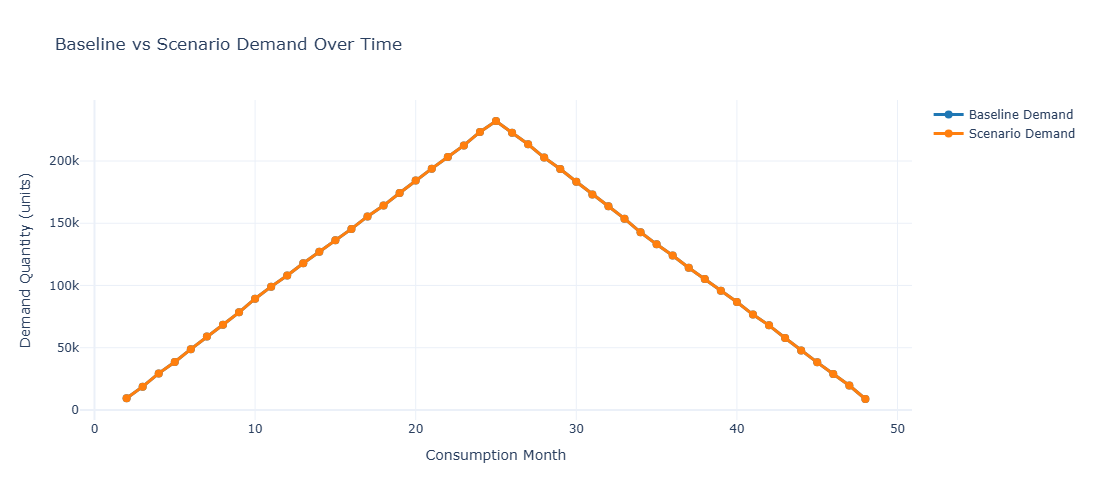

In [8]:
# Aggregate demand by month for visualization
monthly_baseline = baseline_demand.groupby('CONSUMPTION_MONTH')['DEMAND_QTY'].sum().reset_index()
monthly_baseline.columns = ['Month', 'Baseline_Demand']

monthly_scenario = scenario_demand.groupby('CONSUMPTION_MONTH')['DEMAND_QTY'].sum().reset_index()
monthly_scenario.columns = ['Month', 'Scenario_Demand']

monthly_comparison = monthly_baseline.merge(monthly_scenario, on='Month')
monthly_comparison['Variance'] = monthly_comparison['Scenario_Demand'] - monthly_comparison['Baseline_Demand']

# Chart 1: Baseline vs Scenario Demand Over Time
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=monthly_comparison['Month'],
    y=monthly_comparison['Baseline_Demand'],
    mode='lines+markers',
    name='Baseline Demand',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=8)
))

fig1.add_trace(go.Scatter(
    x=monthly_comparison['Month'],
    y=monthly_comparison['Scenario_Demand'],
    mode='lines+markers',
    name='Scenario Demand',
    line=dict(color='#ff7f0e', width=3),
    marker=dict(size=8)
))

fig1.update_layout(
    title='Baseline vs Scenario Demand Over Time',
    xaxis_title='Consumption Month',
    yaxis_title='Demand Quantity (units)',
    hovermode='x unified',
    template='plotly_white',
    height=500
)

fig1.show()

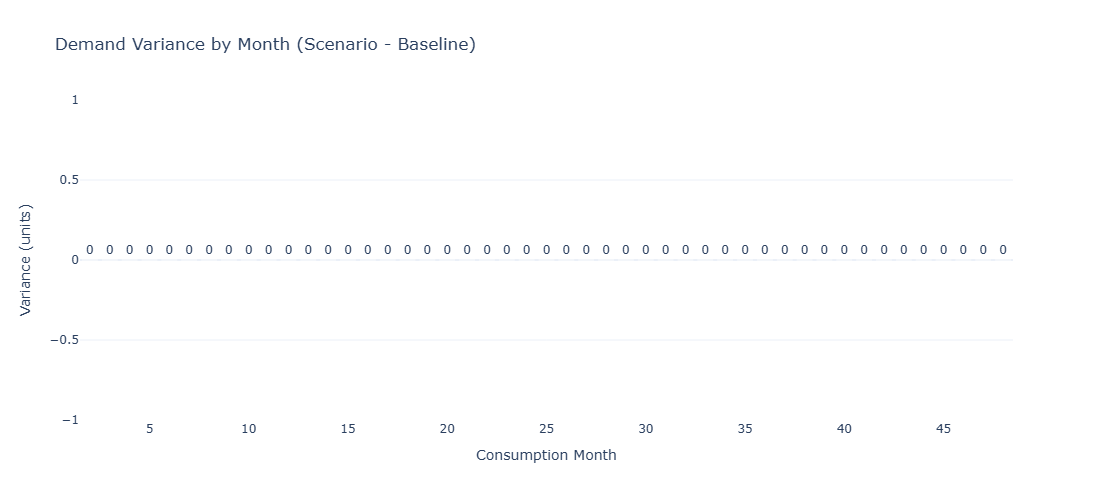

In [9]:
# Chart 2: Demand Variance by Month
fig2 = go.Figure()

colors = ['red' if v < 0 else 'green' for v in monthly_comparison['Variance']]

fig2.add_trace(go.Bar(
    x=monthly_comparison['Month'],
    y=monthly_comparison['Variance'],
    name='Demand Variance',
    marker=dict(color=colors),
    text=monthly_comparison['Variance'].apply(lambda x: f"{x:,.0f}"),
    textposition='outside'
))

fig2.update_layout(
    title='Demand Variance by Month (Scenario - Baseline)',
    xaxis_title='Consumption Month',
    yaxis_title='Variance (units)',
    template='plotly_white',
    height=500,
    showlegend=False
)

fig2.show()

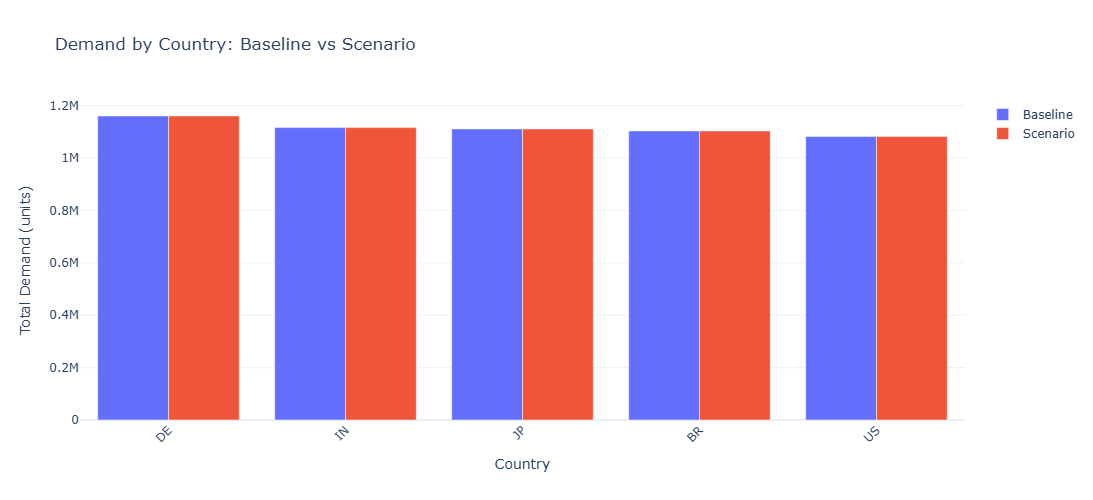

In [10]:
# Chart 3: Demand by Country - Baseline vs Scenario
country_baseline = baseline_demand.groupby('COUNTRY')['DEMAND_QTY'].sum().sort_values(ascending=False)
country_scenario = scenario_demand.groupby('COUNTRY')['DEMAND_QTY'].sum().sort_values(ascending=False)

countries = country_baseline.index.tolist()

fig3 = go.Figure(data=[
    go.Bar(x=countries, y=[country_baseline.get(c, 0) for c in countries], name='Baseline'),
    go.Bar(x=countries, y=[country_scenario.get(c, 0) for c in countries], name='Scenario')
])

fig3.update_layout(
    title='Demand by Country: Baseline vs Scenario',
    xaxis_title='Country',
    yaxis_title='Total Demand (units)',
    barmode='group',
    template='plotly_white',
    height=500,
    xaxis_tickangle=-45
)

fig3.show()

In [11]:
# Chart 4: Comparison Summary Table
summary_table = pd.DataFrame({
    'Metric': [
        'Total Demand (units)',
        'Total Patients',
        'Peak Month Demand',
        'Peak Month Number',
        'Average Monthly Demand',
        'Std Dev (monthly)',
        'Min Monthly Demand',
        'Max Monthly Demand'
    ],
    'Baseline': [
        baseline_demand['DEMAND_QTY'].sum(),
        baseline_demand['PATIENT_COUNT'].sum(),
        monthly_baseline['Baseline_Demand'].max(),
        monthly_baseline.loc[monthly_baseline['Baseline_Demand'].idxmax(), 'Month'],
        monthly_baseline['Baseline_Demand'].mean(),
        monthly_baseline['Baseline_Demand'].std(),
        monthly_baseline['Baseline_Demand'].min(),
        monthly_baseline['Baseline_Demand'].max()
    ],
    'Scenario': [
        scenario_demand['DEMAND_QTY'].sum(),
        scenario_demand['PATIENT_COUNT'].sum(),
        monthly_scenario['Scenario_Demand'].max(),
        monthly_scenario.loc[monthly_scenario['Scenario_Demand'].idxmax(), 'Month'],
        monthly_scenario['Scenario_Demand'].mean(),
        monthly_scenario['Scenario_Demand'].std(),
        monthly_scenario['Scenario_Demand'].min(),
        monthly_scenario['Scenario_Demand'].max()
    ]
})

summary_table['Variance'] = summary_table['Scenario'] - summary_table['Baseline']
summary_table['PCT_Change'] = (
    (summary_table['Scenario'] - summary_table['Baseline']) / summary_table['Baseline'] * 100
).round(2)

print("\n" + "="*100)
print("EXECUTIVE SUMMARY: Baseline vs Scenario")
print("="*100)
print(summary_table.to_string(index=False))


EXECUTIVE SUMMARY: Baseline vs Scenario
                Metric     Baseline     Scenario  Variance  PCT_Change
  Total Demand (units) 5.571768e+06 5.571768e+06       0.0         0.0
        Total Patients 1.910280e+06 1.910280e+06       0.0         0.0
     Peak Month Demand 2.321570e+05 2.321570e+05       0.0         0.0
     Peak Month Number 2.500000e+01 2.500000e+01       0.0         0.0
Average Monthly Demand 1.185483e+05 1.185483e+05       0.0         0.0
     Std Dev (monthly) 6.635499e+04 6.635499e+04       0.0         0.0
    Min Monthly Demand 8.807000e+03 8.807000e+03       0.0         0.0
    Max Monthly Demand 2.321570e+05 2.321570e+05       0.0         0.0


## Key Insights & Business Impact

### Baseline Demand
- **Total Units**: Comprehensive demand across all months, countries, and items
- **Peak Demand**: Identifies the month with highest consumption needs
- **Distribution**: Shows demand patterns by geography

### Scenario Impact (EU 30% Enrollment Reduction)
- **Total Reduction**: Quantifies overall impact of enrollment slowdown
- **Regional Variance**: Shows which countries are most affected
- **Timing**: Indicates when demand starts declining and stabilizes

### Recommendations
1. **Supply Chain Adjustment**: Reduce procurement/manufacturing based on scenario demand
2. **Inventory Management**: Right-size inventory levels for expected scenario demand
3. **Cost Optimization**: Plan labor and facility usage based on revised demand profile
4. **Risk Mitigation**: Prepare contingency plans if enrollment slowdown exceeds 30%

---

### Next Steps
1. Model additional scenarios (different regions, time periods, reduction factors)
2. Combine multiple scenarios for probabilistic forecasting
3. Integrate with financial planning for cost analysis
4. Export results to stakeholder dashboards